# Tutorial 3 - a non-Gaussian DIB profile (Voigt)

Real DIB profiles are not necessarily Gaussian: an unresolved Lorentzian component (a short
carrier lifetime, or unresolved rotational structure) puts flux into the line wings. This
notebook fits the same mock data twice:

* a **6-parameter Gaussian** model, and
* a **7-parameter Voigt** model, `DIB(profile='voigt')`, which adds the Lorentzian half-width
  $\gamma_{\rm DIB}$.

Two Lorentzian strengths are used, both on the same 24-epoch setup:

| case | input $\gamma_{\rm DIB}$ |
|---|---|
| mild (conservative) | $0.10\,\rm\AA$ |
| stress test (paper) | $0.60\,\rm\AA$ |

In [1]:
%matplotlib inline
import json, sys, time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

try:                                     # installed with `pip install -e .`
    import mcmc_rvsd
except ImportError:                      # or run straight from a clone
    sys.path.insert(0, str(Path.cwd().parent / 'src'))
    import mcmc_rvsd
from mcmc_rvsd import SpectralModel, StellarLine, DIB, run_mcmc, plotting
from mcmc_rvsd.io import load_result, load_mock

ROOT = Path.cwd().parent if Path.cwd().name == 'examples' else Path.cwd()
FIG = ROOT / 'docs' / 'figures'
FIG.mkdir(parents=True, exist_ok=True)
RERUN = False             # set to True to redo the MCMC yourself (a few minutes)
print('mcmc_rvsd', mcmc_rvsd.__version__, '|',
      'running from a repository clone' if (ROOT / 'data').is_dir() else 'running from an installed package')

mcmc_rvsd 0.1.0 | running from a repository clone


## 1. The two mock datasets

In [2]:
cases = {'mild (gamma=0.10)': 'mock_6614_voigt', 'stress (gamma=0.60)': 'mock_6614_voigt_gamma06'}
data = {k: load_mock(ROOT / f'data/mock/{v}.npz') for k, v in cases.items()}
for k, d in data.items():
    t = d['dib_truth'].item()
    print(f"{k:>20}: DIB sigma = {t['sigma']:.3f} A, gamma = {t['gamma']:.3f} A, depth = {t['strength']:.3f}")

   mild (gamma=0.10): DIB sigma = 0.545 A, gamma = 0.100 A, depth = 0.049
 stress (gamma=0.60): DIB sigma = 0.545 A, gamma = 0.600 A, depth = 0.049


## 2. Gaussian versus Voigt fits

In [3]:
keys = {'mild (gamma=0.10)': ('mock_6614_voigt_gauss', 'mock_6614_voigt_voigt'),
        'stress (gamma=0.60)': ('mock_6614_voigt06_gauss', 'mock_6614_voigt06_voigt')}
fits = {}
for case, (kg, kv) in keys.items():
    fits[case] = {'Gaussian': load_result(ROOT / f'examples/results/{kg}.npz'),
                  'Voigt': load_result(ROOT / f'examples/results/{kv}.npz')}
    print(case, '| Gaussian label', fits[case]['Gaussian'].label, '| Voigt label', fits[case]['Voigt'].label)

mild (gamma=0.10) | Gaussian label Success | Voigt label Success
stress (gamma=0.60) | Gaussian label Success | Voigt label Success


## 3. What the Gaussian fit does to the width (and what it does to the EW)

In [4]:
from scipy.integrate import simpson
from mcmc_rvsd.profiles import voigt_absorption, gaussian_absorption

for case, d in data.items():
    t = d['dib_truth'].item()
    wave = d['wave_analysis']
    ew_true = simpson(1 - voigt_absorption(wave, t['center'], t['strength'], t['sigma'], t['gamma']), wave)
    print(f'== {case} ==   input sigma = {t["sigma"]:.3f} A, input gamma = {t["gamma"]:.3f} A, input EW = {ew_true:.5f} A')
    for tag, res in fits[case].items():
        q = res.pfit[3:]                       # DIB parameters
        sd, sd_err = q[2], res.perr[3 + 2]
        dev = (sd - t['sigma']) / sd_err
        ew = simpson(1 - (gaussian_absorption(wave, q[0], q[1], q[2]) if tag == 'Gaussian'
                          else voigt_absorption(wave, q[0], q[1], q[2], q[3])), wave)
        extra = '' if tag == 'Gaussian' else f', gamma = {q[3]:.3f} +/- {res.perr[6]:.3f} A'
        print(f'   {tag:>8}: sigma_DIB = {sd:.3f} A ({dev:+.1f} sigma){extra} | EW = {ew:.5f} A ({(ew / ew_true - 1) * 100:+.2f}%) | AIC = {res.aic:.1f}')
    d_ = fits[case]['Voigt'].aic - fits[case]['Gaussian'].aic
    print(f'   Delta AIC (Voigt - Gaussian) = {d_:+.1f}   [negative => Voigt preferred]')
    print()

== mild (gamma=0.10) ==   input sigma = 0.545 A, input gamma = 0.100 A, input EW = 0.07503 A
   Gaussian: sigma_DIB = 0.604 A (+8.6 sigma) | EW = 0.07386 A (-1.55%) | AIC = 1070.0
      Voigt: sigma_DIB = 0.573 A (+1.6 sigma), gamma = 0.056 +/- 0.029 A | EW = 0.07492 A (-0.15%) | AIC = 1069.0
   Delta AIC (Voigt - Gaussian) = -1.0   [negative => Voigt preferred]

== stress (gamma=0.60) ==   input sigma = 0.545 A, input gamma = 0.600 A, input EW = 0.11429 A
   Gaussian: sigma_DIB = 0.945 A (+44.8 sigma) | EW = 0.11114 A (-2.76%) | AIC = 1199.2
      Voigt: sigma_DIB = 0.574 A (+0.9 sigma), gamma = 0.554 +/- 0.041 A | EW = 0.11410 A (-0.17%) | AIC = 1071.0
   Delta AIC (Voigt - Gaussian) = -128.1   [negative => Voigt preferred]



Read the table like this:

* the **width** from the Gaussian fit is inflated - the fit pushes the Lorentzian wings into
  $\sigma_{\rm DIB}$ because a Gaussian simply cannot produce them. With the paper's stress case
  the offset reaches tens of $\sigma$;
* the **equivalent width** is almost unaffected (a few per cent): the missing wings and the
  inflated width compensate. A Gaussian EW measurement is therefore usable, its *width* is not;
* $\Delta$AIC/$\Delta$BIC are strongly negative, i.e. the extra $\gamma$ parameter is justified.

## 4. Where the Gaussian fit fails: the line wings

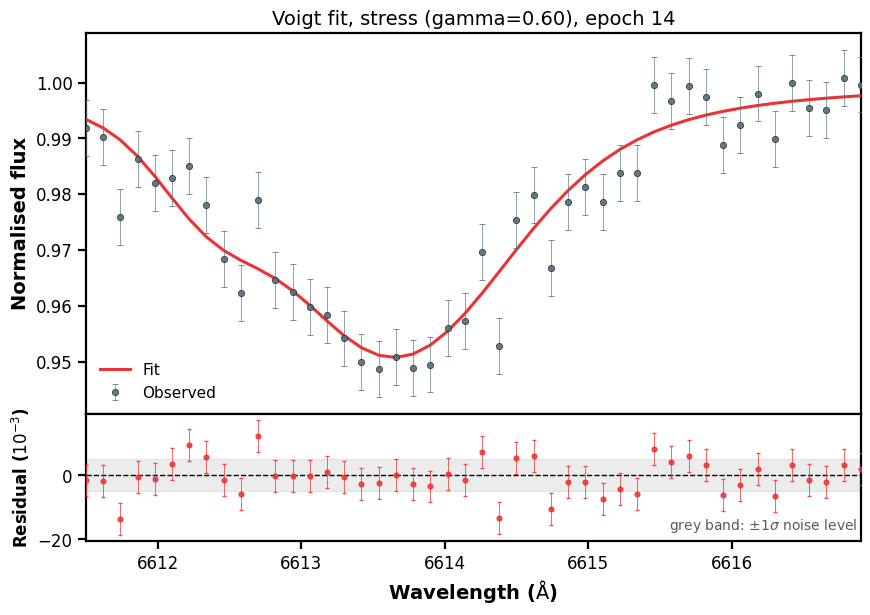

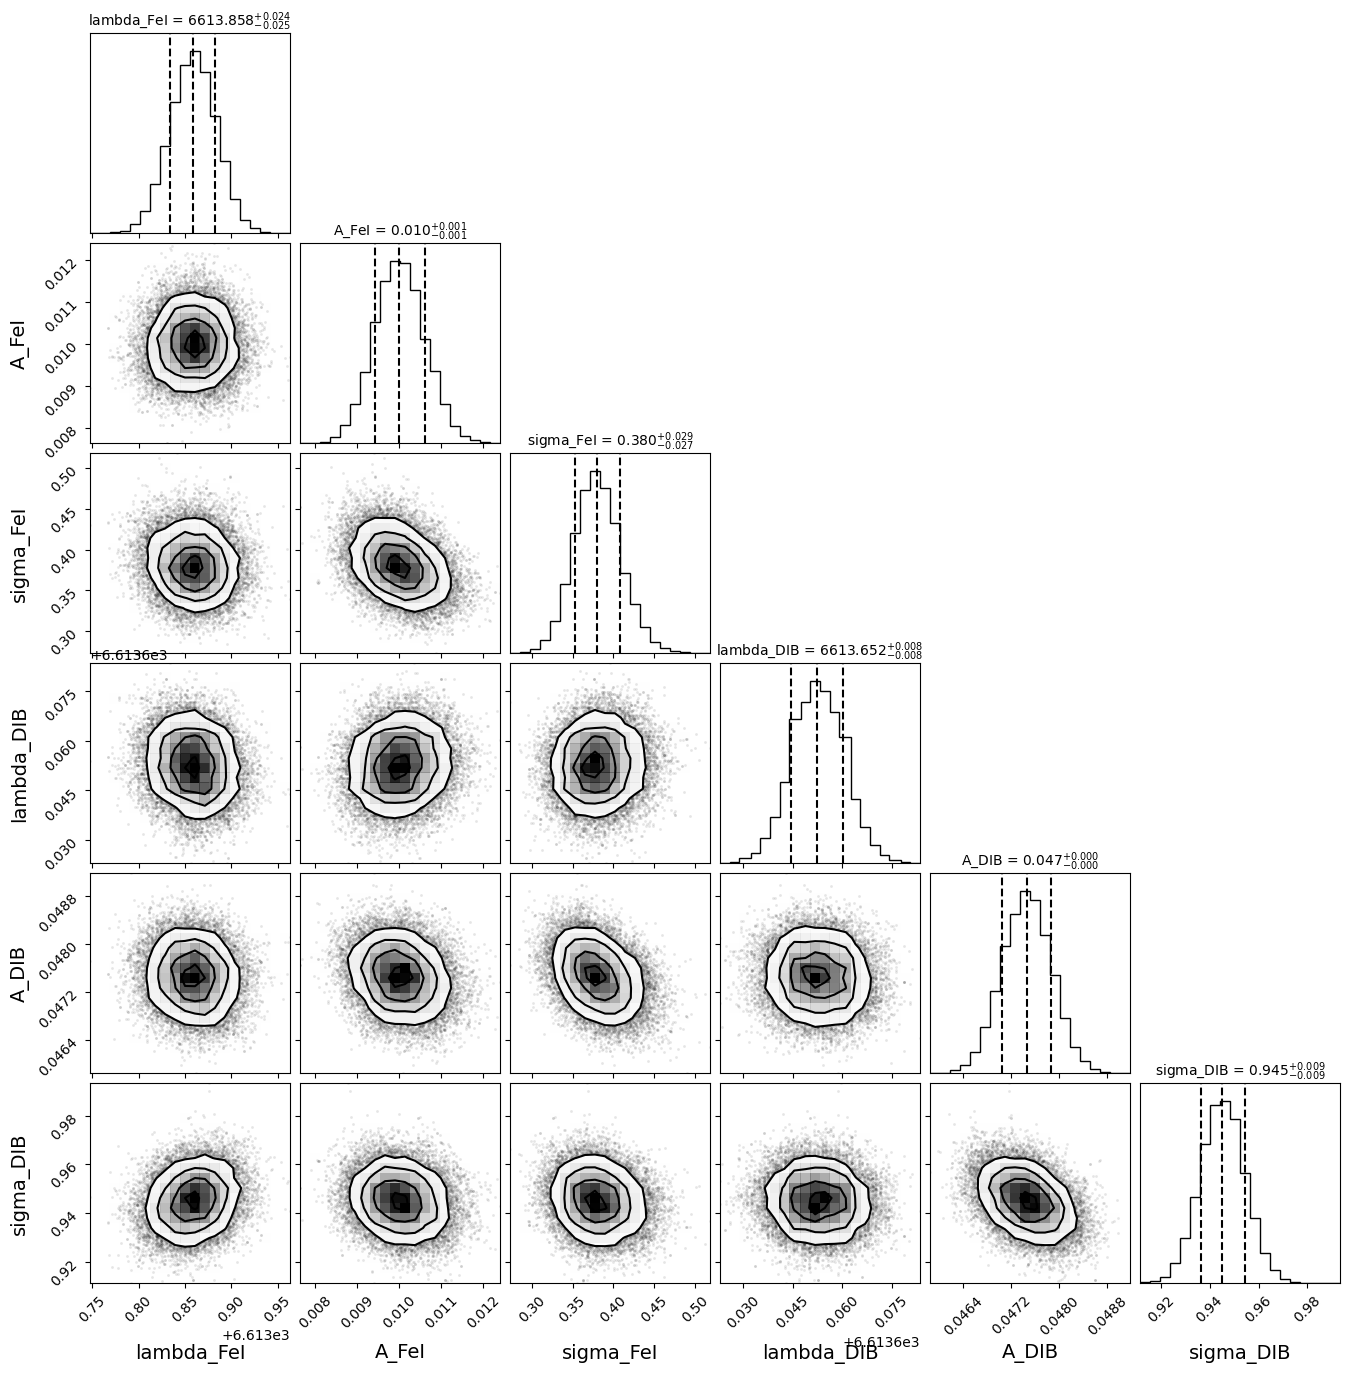

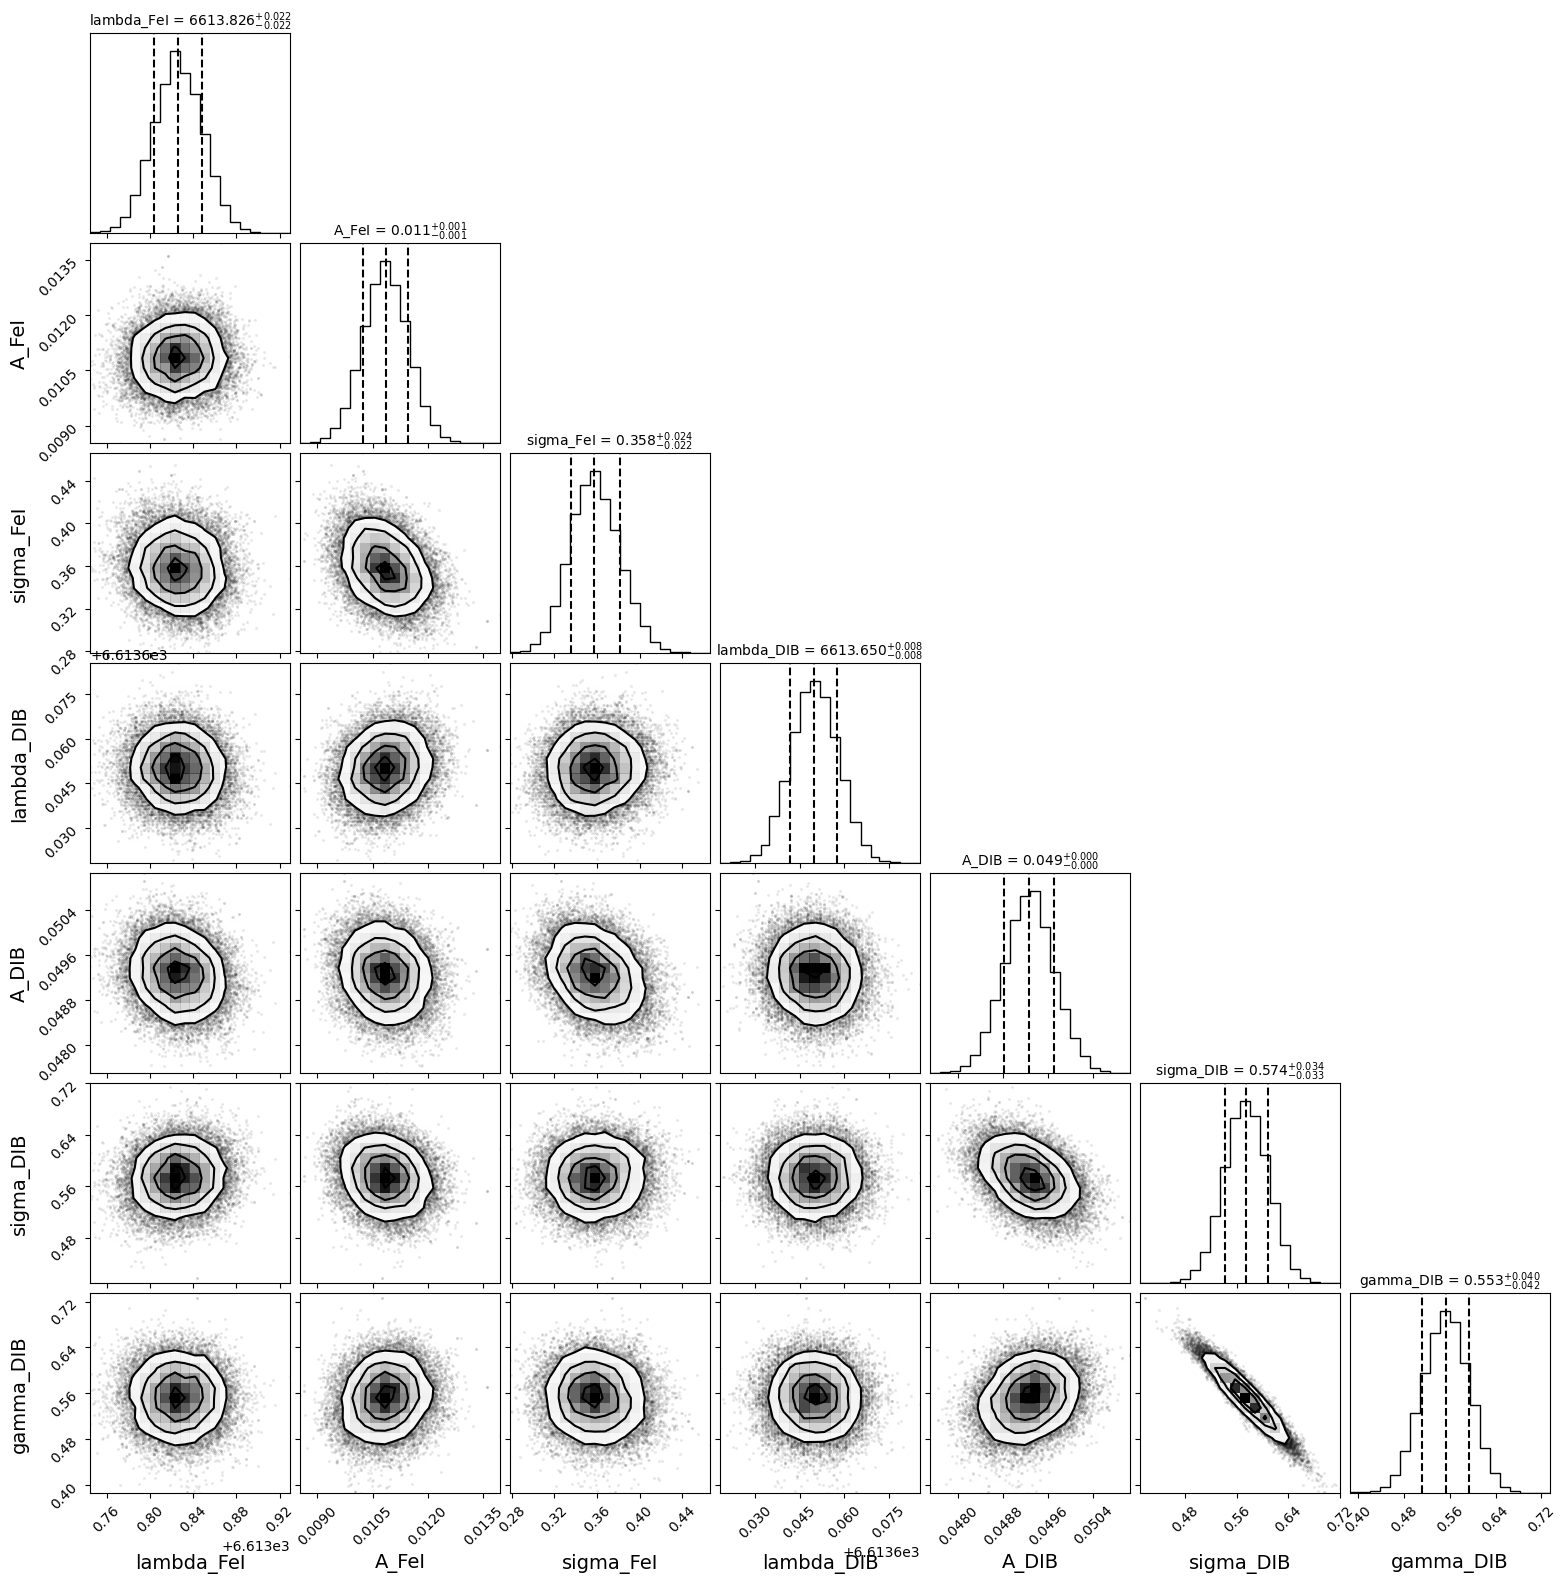

In [5]:
case = 'stress (gamma=0.60)'
d = data[case]
model_v = SpectralModel(stellar_lines=[StellarLine('FeI', 6613.825)],
                        dib=DIB(profile='voigt', gamma0=0.05, gamma_bounds=(0.001, 1.0)))
i = int(np.argmax(np.abs(d['rv_obs'])))
plotting.plot_spectrum_fit(d['wave_analysis'], d['fluxs'], d['y_errs'], d['rv_obs'],
                           model_v, fits[case]['Voigt'].pfit, epoch=i,
                           title=f'Voigt fit, {case}, epoch {i}',
                           out=str(FIG / 'nb03_fit.png'))
plt.show()

model_g = SpectralModel(stellar_lines=[StellarLine('FeI', 6613.825)],
                        dib=DIB(profile='gaussian', sigma_bounds=(0.3, 1.5)))
plotting.plot_corner(fits[case]['Gaussian'].samples, model_g.param_names,
                     out=str(FIG / 'nb03_corner_gaussian.png'))
plt.show()
plotting.plot_corner(fits[case]['Voigt'].samples, model_v.param_names,
                     out=str(FIG / 'nb03_corner_voigt.png'))
plt.show()

## What to take away

* use `DIB(profile='voigt')` whenever the wings carry a non-negligible fraction of the EW -
  the Lorentzian component is then a physical parameter ($\gamma_{\rm DIB}$, i.e. the carrier
  lifetime) rather than a nuisance;
* with a Voigt profile the Gaussian width bias disappears and the EW stays unchanged;
* a Gaussian fit is not "wrong" for the EW, but its width and its width uncertainty must not be
  trusted (see the paper's Table and Figure for $\lambda$6614).